In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# Functions

In [25]:
def compute_proportions(df):
    df["seg_length"] = df["end"] - df["start"]
    summed_ibd_lens = df.groupby("ibd_status").agg(
        {"seg_length": "sum"}
    )
    ibd_props = summed_ibd_lens / summed_ibd_lens.sum()
    return ibd_props


def plot_all_chromosomes(df, title=""):

    colors = {
        "ibd0": "#D3D3D3",
        "ibd1": "#4A90D9",
        "ibd2": "#D94A4A",
    }

    all_chroms = sorted(df["chrom"].unique())
    global_max = df["end"].max()

    fig, axes = plt.subplots(
        nrows=len(all_chroms), ncols=1,
        figsize=(14, max(0.5 * len(all_chroms), 3)),
        squeeze=False
    )
    bar_height = 0.6

    for i, chrom in enumerate(all_chroms):
        ax = axes[i, 0]
        chrom_df = df[df["chrom"] == chrom]

        for _, row in chrom_df.iterrows():
            width = row["end"] - row["start"]
            ax.barh(0, width, left=row["start"], height=bar_height,
                    color=colors[row["ibd_status"]], edgecolor="none")

        ax.set_xlim(0, global_max)
        ax.set_ylim(-0.5, 0.5)
        ax.set_yticks([0])
        # ax.set_yticklabels([chrom_sort_key(chrom)])
        ax.set_yticklabels([chrom], fontsize=16)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.spines["left"].set_visible(False)

        if i < len(all_chroms) - 1:
            ax.set_xlabel("")
            ax.set_xticks([])
        else:
            if global_max > 1_000_000:
                ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x/1e6:.0f}"))
                ax.set_xlabel("Position (Mb)", fontsize=18)
            else:
                ax.set_xlabel("Position (bp)")

    # single legend on the first axis
    legend_patches = [mpatches.Patch(color=c, label=l.upper()) for l, c in colors.items()]
    axes[0, 0].legend(handles=legend_patches, loc="upper right", frameon=False, ncol=3, bbox_to_anchor=(1, 1.9), fontsize=16)
    fig.suptitle(title)
    plt.subplots_adjust(hspace=0.05, top=0.95, bottom=0.05)
    return fig


def convert_truffle_df_format(truffle_df, chrom_size_d):
    ibd1_segs = []
    ibd2_segs = []
    
    factor = 1_000_000
    for inx, row in truffle_seg_df.sort_values(["CHROM","POS"]).iterrows():
        start_pos = row["POS"] * factor
        leng = row["LENGTH"] * factor
        end_pos = start_pos + leng
        chrom = row["CHROM"]
        ibd_type = row["TYPE"]
        ele = (chrom, start_pos, end_pos)
        if ibd_type == "IBD1":
            ibd1_segs.append(ele)
        elif ibd_type == "IBD2":
            ibd2_segs.append(ele)
        else:
            print(inx)
    truffle_df = reconcile_ibd_segments(ibd1_segs, ibd2_segs, chrom_size_d)

    new_rows = []
    # pad with ibd 0 until end of chrom
    for chrom, size in chrom_size_d.items():
        chrom_df = truffle_df.loc[truffle_df["chrom"] == int(chrom)]
        max_end = chrom_df["end"].max()
        if max_end < size:
            new_row = [int(chrom), max_end, size, "ibd0"]
            new_rows.append(new_row)
    padded_df = pd.DataFrame(new_rows, columns=["chrom", "start", "end", "ibd_status"])
    truff_df = pd.concat([padded_df, truffle_df]).sort_values(["chrom", "start"])
    return truff_df

def reconcile_ibd_segments(ibd1_segments, ibd2_segments, chr_sizes_d):
    ibd2 = sorted(ibd2_segments, key=lambda x: (x[0], x[1]))
    ibd1_out = []
    ibd1_out_d = {}
    for chrom, start, end in sorted(ibd1_segments, key=lambda x: (x[0], x[1])):
        remaining = [(start, end)]
        for s2_chrom, s2_start, s2_end in ibd2:
            if s2_chrom != chrom:
                continue
            if s2_start > end:
                break
            new_remaining = []
            for r_start, r_end in remaining:
                if s2_end < r_start or s2_start > r_end:
                    new_remaining.append((r_start, r_end))
                else:
                    if r_start < s2_start:
                        new_remaining.append((r_start, s2_start - 1))
                    if r_end > s2_end:
                        new_remaining.append((s2_end + 1, r_end))
            remaining = new_remaining
        for r_start, r_end in remaining:
            ibd1_out.append((chrom, r_start, r_end))
            current_eles = ibd1_out_d.get(chrom, [])
            current_eles.append((r_start, r_end, "ibd1"))
            ibd1_out_d[chrom] = current_eles
    ibd2_out_d = {}
    for chrom, start, end in ibd2_segments:
        lis = ibd2_out_d.get(chrom, [])
        lis.append((start, end, "ibd2"))
        ibd2_out_d[chrom] = lis

    chroms = sorted(chr_sizes_d.keys())
    data_d = {"chrom": [], "start": [], "end": [], "ibd_status": []}
    for chrom in chroms:
        chrom = int(chrom)
        ibd1_eles = ibd1_out_d.get(chrom, [])
        ibd2_eles = ibd2_out_d.get(chrom, [])
        comb_lis = sorted(ibd1_eles + ibd2_eles)

        chrom_len = chr_sizes_d.get(chrom, 0)
        cursor = 0

        if len(comb_lis) == 0:
            chrom_size = chr_sizes_d[str(chrom)]
            data_d["chrom"].append(chrom)
            data_d["start"].append(0)
            data_d["end"].append(chrom_size)
            data_d["ibd_status"].append("ibd0")
        for start, end, ibd_state in comb_lis:
            if start > cursor:
                data_d["chrom"].append(chrom)
                data_d["start"].append(cursor)
                data_d["end"].append(start)
                data_d["ibd_status"].append("ibd0")
            data_d["chrom"].append(chrom)
            data_d["start"].append(start)
            data_d["end"].append(end)
            data_d["ibd_status"].append(ibd_state)
            cursor = end

        if cursor < chrom_len:
            data_d["chrom"].append(chrom)
            data_d["start"].append(cursor)
            data_d["end"].append(chrom_len)
            data_d["ibd_status"].append("ibd0")

    df = pd.DataFrame(data_d)
    return df



def compare_two_dfs(df1, df2):
    chrom_set_1 = set(df1["chrom"])
    chrom_set_2 = set(df2["chrom"])
    if not chrom_set_1 == chrom_set_2:
        print("ERROR MISMATCHING CHROMS")
        print(chrom_set_1 - chrom_set_2)
        print(chrom_set_2 - chrom_set_1)
        assert chrom_set_1 == chrom_set_2

    res_d = {"chrom": [], "start": [], "end": [], "ibd_status_1": [], "ibd_status_2": []}

    for chrom in sorted(chrom_set_1):
        c1 = df1[df1["chrom"] == chrom].sort_values("start")
        c2 = df2[df2["chrom"] == chrom].sort_values("start")

        # collect all unique breakpoints
        breakpoints = sorted(set(
            c1["start"].tolist() + c1["end"].tolist() +
            c2["start"].tolist() + c2["end"].tolist()
        ))

        for i in range(len(breakpoints) - 1):
            
            seg_start = breakpoints[i]
            seg_end = breakpoints[i + 1]
            
            mid = (seg_start + seg_end) / 2
            
            # find status in df1
            mask1 = (c1["start"] <= mid) & (c1["end"] > mid)
            status1 = c1.loc[mask1, "ibd_status"].values
            if len(status1) != 1:
                print("1")
                print(chrom, seg_start, seg_end, mid)
                print(c1.loc[mask1])
            status1 = status1[0] if len(status1) > 0 else "undefined"

            # find status in df2
            mask2 = (c2["start"] <= mid) & (c2["end"] > mid)
            status2 = c2.loc[mask2, "ibd_status"].values
            if len(status2) != 1:
                print("2")
                print(chrom, seg_start, seg_end, mid)
                print(c2.loc[mask2])
            status2 = status2[0] if len(status2) > 0 else "undefined"
            

            res_d["chrom"].append(chrom)
            res_d["start"].append(seg_start)
            res_d["end"].append(seg_end)
            res_d["ibd_status_1"].append(status1)
            res_d["ibd_status_2"].append(status2)

    return pd.DataFrame(res_d)

def plot_status_heatmap(compare_df, method_1_label = "Method 1", method_2_label = "Method 2"):
    """
    Plot a heatmap of total basepairs for each (ibd_status_1, ibd_status_2) pair.
    """
    pivot = compare_df.groupby(["ibd_status_1", "ibd_status_2"])["length"].sum().reset_index()
    matrix = pivot.pivot(index="ibd_status_1", columns="ibd_status_2", values="length").fillna(0)

    # order consistently
    order = ["ibd0", "ibd1", "ibd2", "undefined"]
    order = [o for o in order if o in matrix.index or o in matrix.columns]
    matrix = matrix.reindex(index=order, columns=order, fill_value=0)

    fig, ax = plt.subplots(figsize=(8, 6))
    im = ax.imshow(matrix.values, cmap="Blues", aspect="auto")

    # annotate cells with Mb values
    for i in range(len(matrix.index)):
        for j in range(len(matrix.columns)):
            val = matrix.values[i, j]
            label = f"{val / 1e6:.1f} Mb"
            color = "white" if val > matrix.values.max() * 0.5 else "black"
            ax.text(j, i, label, ha="center", va="center", color=color, fontsize=10)

    ax.set_xticks(range(len(matrix.columns)))
    ax.set_xticklabels(matrix.columns, fontsize=11)
    ax.set_yticks(range(len(matrix.index)))
    ax.set_yticklabels(matrix.index, fontsize=11)
    ax.set_xlabel(method_2_label, fontsize=12)
    ax.set_ylabel(method_1_label, fontsize=12)
    ax.set_title("IBD Status Agreement (total basepairs)", fontsize=14)
    fig.colorbar(im, ax=ax, label="Basepairs")
    plt.tight_layout()


# Plot

In [ ]:
## Plot Results of Chr20 ##

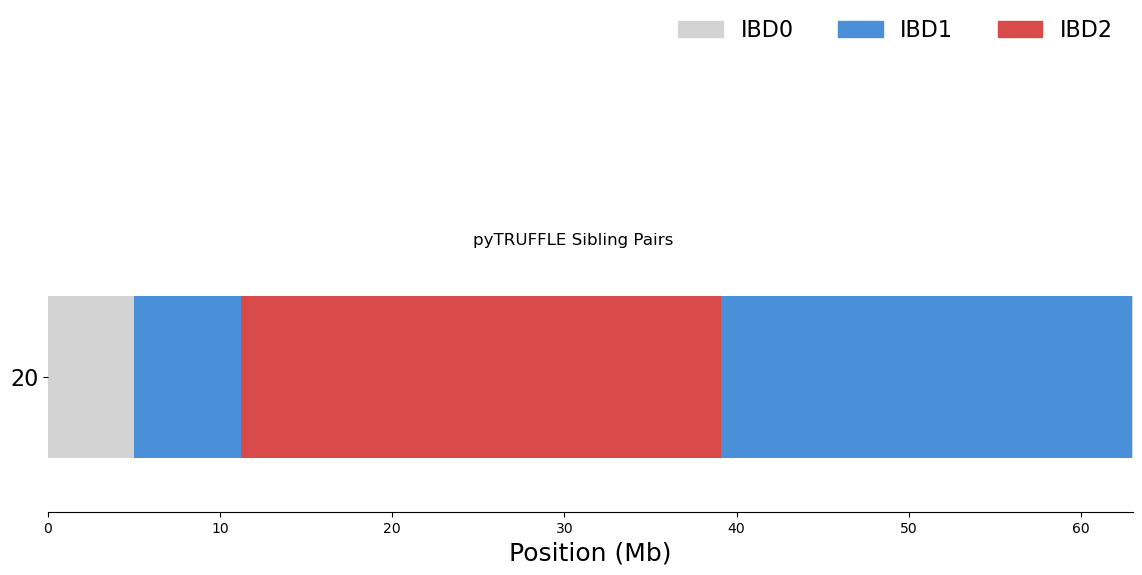

In [4]:
pytruffle_calls_p = "./HG00581_vs_HG00635_chr20/ibd_segments.tsv"
pytruffle_df = pd.read_csv(pytruffle_calls_p, sep="\t")

compute_proportions(pytruffle_df)
fig = plot_all_chromosomes(pytruffle_df, title="pyTRUFFLE Sibling Pairs")

In [8]:
## Plot full results contained in repo

In [6]:
pytruffle_calls_p = "./HG00581_vs_HG00635/ibd_segments.tsv"
pytruffle_df = pd.read_csv(pytruffle_calls_p, sep="\t")

compute_proportions(pytruffle_df)


,seg_length
ibd_status,
ibd0,0.242497
ibd1,0.524143
ibd2,0.233361


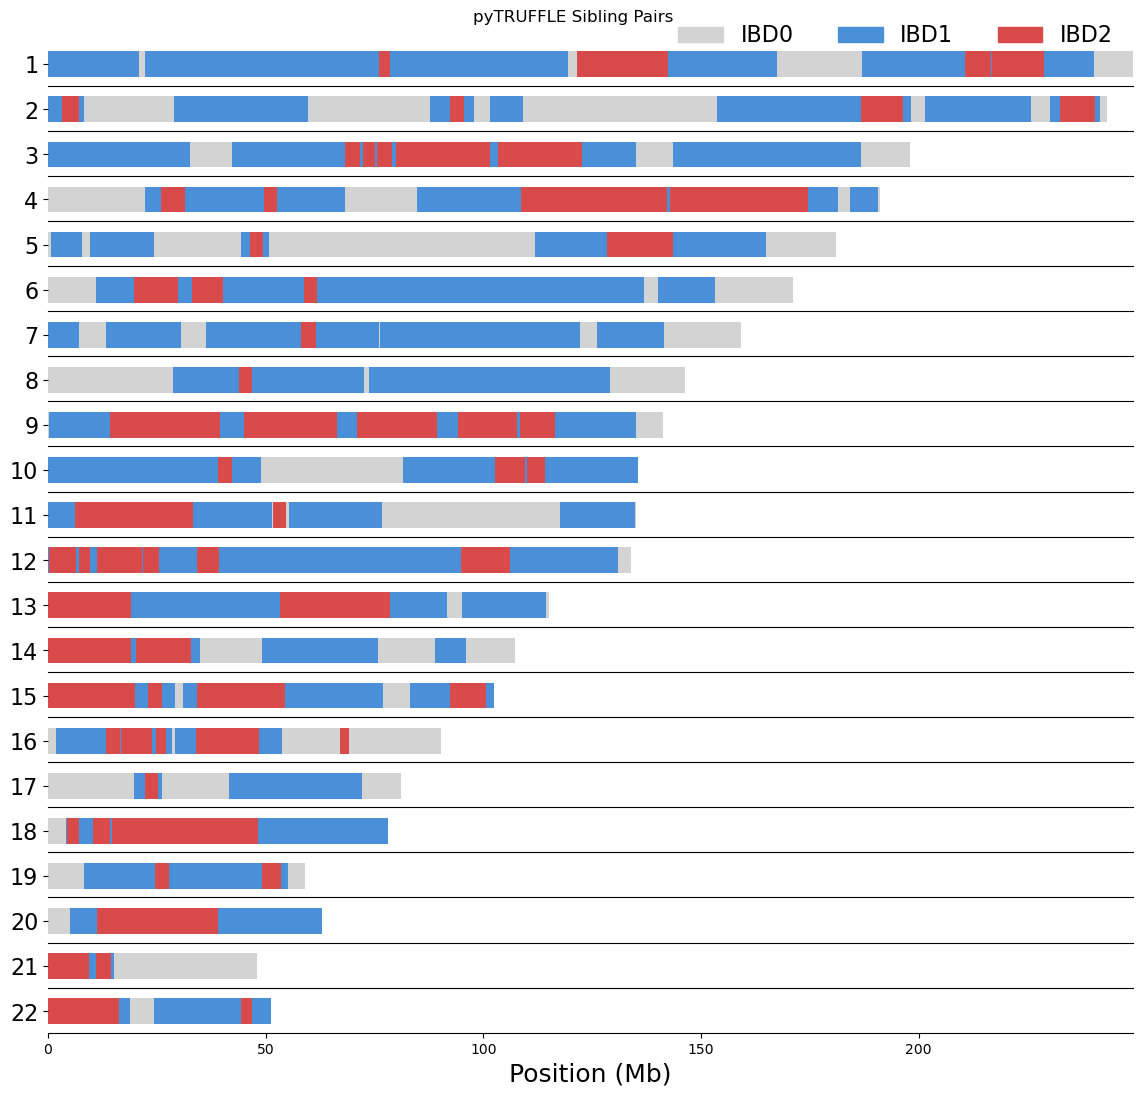

In [7]:
fig = plot_all_chromosomes(pytruffle_df, title="pyTRUFFLE Sibling Pairs")

In [ ]:
## Plot Truffle Results

In [21]:

chrom_size_d = {
    "1": 249250621,
    "2": 243199373,
    "3": 198022430,
    "4": 191154276,
    "5": 180915260,
    "6": 171115067,
    "7": 159138663,
    "8": 146364022,
    "9": 141213431,
    "10": 135534747,
    "11": 135006516,
    "12": 133851895,
    "13": 115169878,
    "14": 107349540,
    "15": 102531392,
    "16": 90354753,
    "17": 81195210,
    "18": 78077248,
    "19": 59128983,
    "20": 63025520,
    "21": 48129895,
    "22": 51304566,
}

In [22]:
# truffle_calls_p = "./HG00581_vs_HG00635_TRUFFLE/truffle_calls.tsv"
# truffle_df = pd.read_csv(pytruffle_calls_p, sep="\t")

truffle_seg_path = "/Users/jonah/Downloads/truffle-2.segments"
truffle_seg_df = pd.read_csv(truffle_seg_path, sep=r"\s+")

truffle_df = convert_truffle_df_format(truffle_seg_df, chrom_size_d = chrom_size_d)


compute_proportions(truffle_df)


,seg_length
ibd_status,
ibd0,0.379957
ibd1,0.451340
ibd2,0.168704


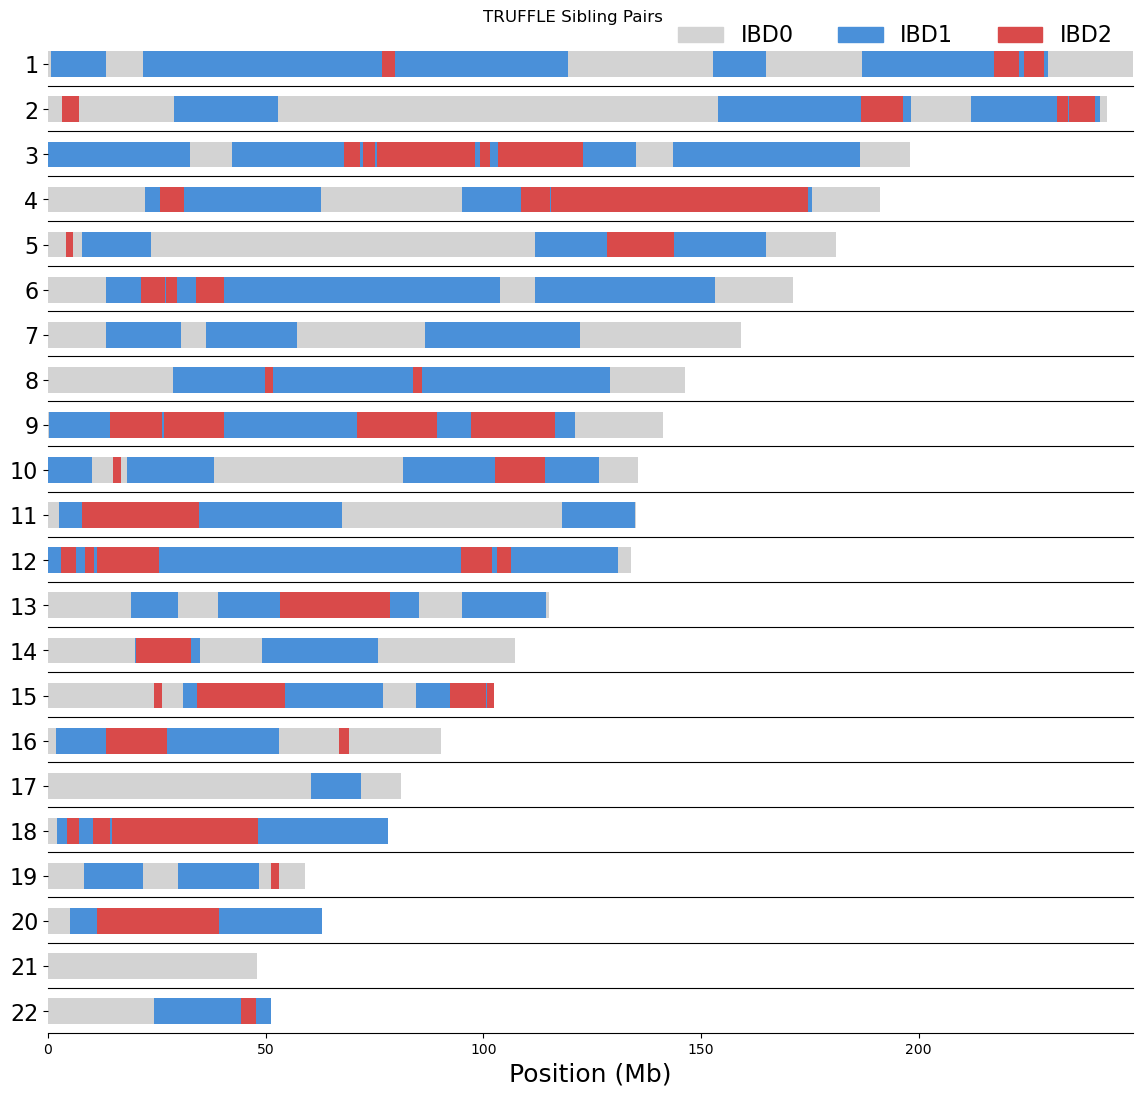

In [24]:
fig = plot_all_chromosomes(truffle_df, title="TRUFFLE Sibling Pairs")

In [ ]:
# Compare TRUFFLE and pyTRUFFLE Directly

In [26]:
compare_df = compare_two_dfs(pytruffle_df, truffle_df)

compare_df["is_matching"] = compare_df["ibd_status_1"] == compare_df["ibd_status_2"]
compare_df["length"] = compare_df["end"] - compare_df["start"]

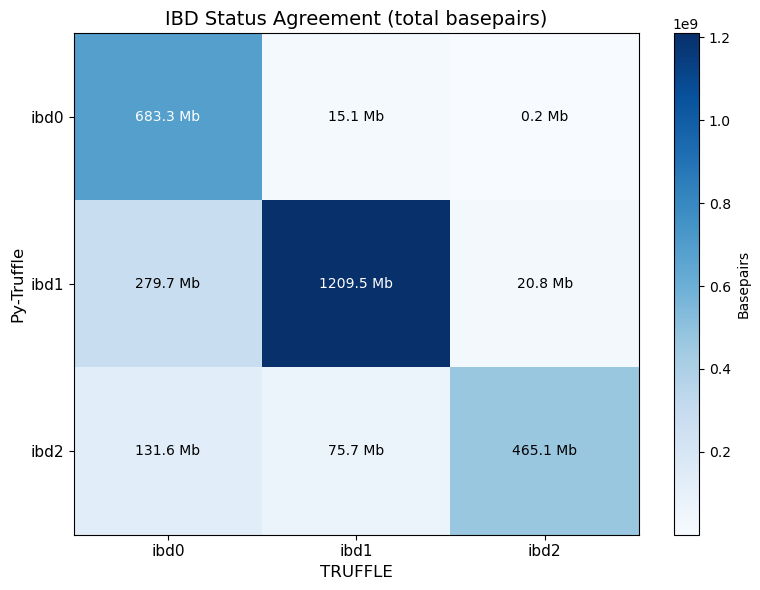

In [27]:
plot_status_heatmap(compare_df, method_1_label="Py-Truffle", method_2_label="TRUFFLE")